In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load all 5 datasets
anxiety = pd.read_csv('anxiety.csv', skiprows=1)
depression = pd.read_csv('depression.csv', skiprows=1)
insomnia = pd.read_csv('insomnia.csv', skiprows=1)
loneliness = pd.read_csv('loneliness.csv', skiprows=1)
stress = pd.read_csv('stress.csv', skiprows=1)

# Rename columns
for df, name in zip([anxiety, depression, insomnia, loneliness, stress], 
                    ['anxiety', 'depression', 'insomnia', 'loneliness', 'stress']):
    df.columns = ['Month', name]

# Merge all into one dataframe
df = anxiety.copy()
for other in [depression, insomnia, loneliness, stress]:
    df = df.merge(other, on='Month')

# Convert Month to datetime
df['Month'] = pd.to_datetime(df['Month'])

print(df.shape)
print(df.head())


(266, 6)
       Month  anxiety  depression  insomnia  loneliness  stress
0 2004-01-02       28          95        48          59      63
1 2004-01-03       31         100        49          61      67
2 2004-01-04       28          97        47          60      67
3 2004-01-05       28          88        44          58      60
4 2004-01-06       27          71        39          44      52


In [2]:
# Set Month as index
df = df.set_index('Month')

# Resample to monthly average (in case of weekly data)
df_monthly = df.resample('MS').mean()

print(f"Date range: {df_monthly.index.min()} to {df_monthly.index.max()}")
print(f"Total months: {len(df_monthly)}")
print("\nBasic statistics:")
print(df_monthly.describe().round(2))

Date range: 2004-01-01 00:00:00 to 2026-01-01 00:00:00
Total months: 265

Basic statistics:
       anxiety  depression  insomnia  loneliness  stress
count    23.00       23.00     23.00       23.00   23.00
mean     45.93       56.67     60.36       46.26   46.18
std      18.09        9.62     12.72        9.43    8.87
min      24.42       45.75     41.17       34.17   39.50
25%      29.14       50.58     54.46       42.83   40.71
50%      42.67       53.67     58.00       44.25   43.67
75%      60.75       58.29     70.29       47.42   46.75
max      86.00       83.73     94.00       83.00   79.33


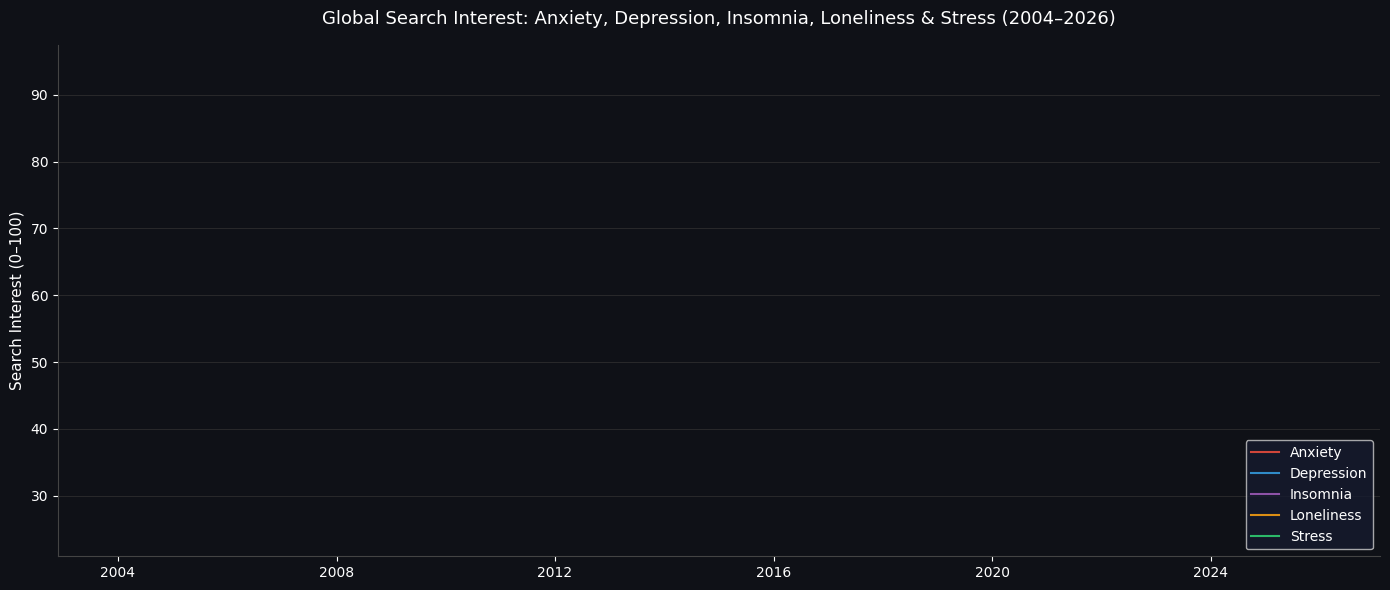

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#E74C3C', '#3498DB', '#9B59B6', '#F39C12', '#2ECC71']
terms = ['anxiety', 'depression', 'insomnia', 'loneliness', 'stress']

for term, color in zip(terms, colors):
    ax.plot(df_monthly.index, df_monthly[term], label=term.capitalize(), 
            color=color, linewidth=1.5, alpha=0.9)

ax.set_facecolor('#0F1117')
fig.patch.set_facecolor('#0F1117')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Global Search Interest: Anxiety, Depression, Insomnia, Loneliness & Stress (2004–2026)', 
             fontsize=13, pad=15)
ax.set_ylabel('Search Interest (0–100)', fontsize=11)
ax.legend(facecolor='#161B2E', labelcolor='white', fontsize=10)
ax.grid(axis='y', color='#333', linewidth=0.5)

plt.tight_layout()
plt.savefig('overview_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print(df_monthly.head(10))
print(df_monthly.dtypes)

              anxiety  depression  insomnia  loneliness     stress
Month                                                             
2004-01-01  29.272727   83.727273      44.0   52.454545  58.909091
2004-02-01        NaN         NaN       NaN         NaN        NaN
2004-03-01        NaN         NaN       NaN         NaN        NaN
2004-04-01        NaN         NaN       NaN         NaN        NaN
2004-05-01        NaN         NaN       NaN         NaN        NaN
2004-06-01        NaN         NaN       NaN         NaN        NaN
2004-07-01        NaN         NaN       NaN         NaN        NaN
2004-08-01        NaN         NaN       NaN         NaN        NaN
2004-09-01        NaN         NaN       NaN         NaN        NaN
2004-10-01        NaN         NaN       NaN         NaN        NaN
anxiety       float64
depression    float64
insomnia      float64
loneliness    float64
stress        float64
dtype: object


In [5]:
# Reset and redo - weekly data needs different resampling
df_monthly = df.resample('ME').mean()

# Drop any remaining NaN rows
df_monthly = df_monthly.dropna()

print(f"Date range: {df_monthly.index.min()} to {df_monthly.index.max()}")
print(f"Total months: {len(df_monthly)}")
print(df_monthly.head(10))

Date range: 2004-01-31 00:00:00 to 2026-01-31 00:00:00
Total months: 23
              anxiety  depression   insomnia  loneliness     stress
Month                                                              
2004-01-31  29.272727   83.727273  44.000000   52.454545  58.909091
2005-01-31  29.583333   78.916667  47.750000   46.833333  54.333333
2006-01-31  27.583333   69.166667  42.666667   48.000000  47.916667
2007-01-31  25.083333   58.333333  41.166667   37.583333  43.666667
2008-01-31  24.416667   56.916667  43.583333   34.166667  43.750000
2009-01-31  24.833333   53.666667  57.250000   38.333333  42.000000
2010-01-31  26.916667   50.750000  58.000000   43.750000  40.416667
2011-01-31  29.000000   49.500000  56.333333   45.750000  40.333333
2012-01-31  33.500000   49.416667  54.250000   43.250000  39.500000
2013-01-31  35.833333   48.583333  54.666667   42.916667  39.666667


In [6]:
print(df.head(20))
print(f"\nTotal rows in raw data: {len(df)}")
print(f"\nFirst few dates: {df.index[:5].tolist()}")

            anxiety  depression  insomnia  loneliness  stress
Month                                                        
2004-01-02       28          95        48          59      63
2004-01-03       31         100        49          61      67
2004-01-04       28          97        47          60      67
2004-01-05       28          88        44          58      60
2004-01-06       27          71        39          44      52
2004-01-07       30          67        43          45      48
2004-01-08       30          69        42          44      51
2004-01-09       32          81        41          49      60
2004-01-10       30          86        44          50      62
2004-01-11       31          88        42          57      64
2004-01-12       27          79        45          50      54
2005-01-01       30          78        53          47      51
2005-01-02       31          88        50          46      61
2005-01-03       30          90        47          51      57
2005-01-

In [7]:
# Correct monthly resampling for weekly data
df_monthly = df.resample('M').mean()
df_monthly = df_monthly.dropna()

print(f"Total months: {len(df_monthly)}")
print(df_monthly.head(10))

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [8]:
# Alternative approach - extract year-month and group manually
df_monthly = df.copy()
df_monthly['YearMonth'] = df_monthly.index.to_period('M')
df_monthly = df_monthly.groupby('YearMonth').mean()
df_monthly.index = df_monthly.index.to_timestamp()

print(f"Total months: {len(df_monthly)}")
print(df_monthly.head(10))

Total months: 23
              anxiety  depression   insomnia  loneliness     stress
YearMonth                                                          
2004-01-01  29.272727   83.727273  44.000000   52.454545  58.909091
2005-01-01  29.583333   78.916667  47.750000   46.833333  54.333333
2006-01-01  27.583333   69.166667  42.666667   48.000000  47.916667
2007-01-01  25.083333   58.333333  41.166667   37.583333  43.666667
2008-01-01  24.416667   56.916667  43.583333   34.166667  43.750000
2009-01-01  24.833333   53.666667  57.250000   38.333333  42.000000
2010-01-01  26.916667   50.750000  58.000000   43.750000  40.416667
2011-01-01  29.000000   49.500000  56.333333   45.750000  40.333333
2012-01-01  33.500000   49.416667  54.250000   43.250000  39.500000
2013-01-01  35.833333   48.583333  54.666667   42.916667  39.666667


In [9]:
# Correct approach using resample with modern pandas alias
df_monthly = df.resample('ME').mean()
df_monthly = df_monthly.dropna()

print(f"Total months: {len(df_monthly)}")
print(df_monthly.head(10))

Total months: 23
              anxiety  depression   insomnia  loneliness     stress
Month                                                              
2004-01-31  29.272727   83.727273  44.000000   52.454545  58.909091
2005-01-31  29.583333   78.916667  47.750000   46.833333  54.333333
2006-01-31  27.583333   69.166667  42.666667   48.000000  47.916667
2007-01-31  25.083333   58.333333  41.166667   37.583333  43.666667
2008-01-31  24.416667   56.916667  43.583333   34.166667  43.750000
2009-01-31  24.833333   53.666667  57.250000   38.333333  42.000000
2010-01-31  26.916667   50.750000  58.000000   43.750000  40.416667
2011-01-31  29.000000   49.500000  56.333333   45.750000  40.333333
2012-01-31  33.500000   49.416667  54.250000   43.250000  39.500000
2013-01-31  35.833333   48.583333  54.666667   42.916667  39.666667


In [10]:
df_monthly = df.copy()
df_monthly['year']  = df_monthly.index.year
df_monthly['month'] = df_monthly.index.month

df_monthly = (df_monthly
              .groupby(['year', 'month'])
              .mean()
              .reset_index())

# Rebuild a proper datetime index from year + month
df_monthly.index = pd.to_datetime(
    df_monthly['year'].astype(str) + '-' + df_monthly['month'].astype(str).str.zfill(2) + '-01'
)
df_monthly = df_monthly.drop(columns=['year', 'month']).sort_index()

print(f"Total months: {len(df_monthly)}")
print(df_monthly.head(10))

Total months: 23
              anxiety  depression   insomnia  loneliness     stress
2004-01-01  29.272727   83.727273  44.000000   52.454545  58.909091
2005-01-01  29.583333   78.916667  47.750000   46.833333  54.333333
2006-01-01  27.583333   69.166667  42.666667   48.000000  47.916667
2007-01-01  25.083333   58.333333  41.166667   37.583333  43.666667
2008-01-01  24.416667   56.916667  43.583333   34.166667  43.750000
2009-01-01  24.833333   53.666667  57.250000   38.333333  42.000000
2010-01-01  26.916667   50.750000  58.000000   43.750000  40.416667
2011-01-01  29.000000   49.500000  56.333333   45.750000  40.333333
2012-01-01  33.500000   49.416667  54.250000   43.250000  39.500000
2013-01-01  35.833333   48.583333  54.666667   42.916667  39.666667


In [11]:
print("Shape:", df.shape)
print("Index type:", type(df.index))
print("Index dtype:", df.index.dtype)
print("\nFirst 5 index values:")
print(df.index[:5])
print("\nLast 5 index values:")
print(df.index[-5:])
print("\nIndex freq:", df.index.freq)
print("\nUnique years:", df.index.year.nunique())
print("Unique months:", df.index.month.nunique())

Shape: (266, 5)
Index type: <class 'pandas.DatetimeIndex'>
Index dtype: datetime64[us]

First 5 index values:
DatetimeIndex(['2004-01-02', '2004-01-03', '2004-01-04', '2004-01-05',
               '2004-01-06'],
              dtype='datetime64[us]', name='Month', freq=None)

Last 5 index values:
DatetimeIndex(['2025-01-11', '2025-01-12', '2026-01-01', '2026-01-02',
               '2026-01-03'],
              dtype='datetime64[us]', name='Month', freq=None)

Index freq: None

Unique years: 23
Unique months: 1


In [12]:
import pandas as pd
import os

DATA_DIR = r'C:\Users\admin\OneDrive\Desktop\human-concern-timeseries'

def load_trends_csv(filename, concern_name):
    path = os.path.join(DATA_DIR, filename)
    # Google Trends CSVs have 2 junk header rows
    df = pd.read_csv(path, skiprows=2, header=0)
    df.columns = ['Month', concern_name]
    df['Month'] = pd.to_datetime(df['Month'])
    df = df.set_index('Month')
    df[concern_name] = pd.to_numeric(df[concern_name], errors='coerce')
    return df

anxiety    = load_trends_csv('anxiety.csv',    'anxiety')
depression = load_trends_csv('depression.csv', 'depression')
insomnia   = load_trends_csv('insomnia.csv',   'insomnia')
loneliness = load_trends_csv('loneliness.csv', 'loneliness')
stress     = load_trends_csv('stress.csv',     'stress')

# Merge horizontally on the date index
df = pd.concat([anxiety, depression, insomnia, loneliness, stress], axis=1)
df = df.sort_index().dropna()

print("Shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())
print("Unique months:", df.index.month.nunique())
print("\n", df.head(10))

Shape: (265, 5)
Date range: 2004-01-03 00:00:00 → 2026-01-03 00:00:00
Unique months: 1

             anxiety  depression  insomnia  loneliness  stress
Month                                                        
2004-01-03       31         100        49          61      67
2004-01-04       28          97        47          60      67
2004-01-05       28          88        44          58      60
2004-01-06       27          71        39          44      52
2004-01-07       30          67        43          45      48
2004-01-08       30          69        42          44      51
2004-01-09       32          81        41          49      60
2004-01-10       30          86        44          50      62
2004-01-11       31          88        42          57      64
2004-01-12       27          79        45          50      54


In [13]:
import os

DATA_DIR = r'C:\Users\admin\OneDrive\Desktop\human-concern-timeseries'

# Read the raw file with NO parsing to see exactly what's inside
raw = pd.read_csv(os.path.join(DATA_DIR, 'anxiety.csv'), header=None, nrows=10)
print(raw.to_string())

            0        1
0        Time  anxiety
1  01/01/2004       26
2  01/02/2004       28
3  01/03/2004       31
4  01/04/2004       28
5  01/05/2004       28
6  01/06/2004       27
7  01/07/2004       30
8  01/08/2004       30
9  01/09/2004       32


In [14]:
import pandas as pd
import os

DATA_DIR = r'C:\Users\admin\OneDrive\Desktop\human-concern-timeseries'

def load_trends_csv(filename, concern_name):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, header=0)                          # no skiprows — row 0 IS the header
    df.columns = ['Date', concern_name]
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')  # MM/DD/YYYY
    df = df.set_index('Date')
    df[concern_name] = pd.to_numeric(df[concern_name], errors='coerce')
    return df

anxiety    = load_trends_csv('anxiety.csv',    'anxiety')
depression = load_trends_csv('depression.csv', 'depression')
insomnia   = load_trends_csv('insomnia.csv',   'insomnia')
loneliness = load_trends_csv('loneliness.csv', 'loneliness')
stress     = load_trends_csv('stress.csv',     'stress')

# Merge horizontally
df = pd.concat([anxiety, depression, insomnia, loneliness, stress], axis=1)
df = df.sort_index().dropna()

print("=== df (daily) ===")
print("Shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())
print("Unique months:", df.index.month.nunique())
print(df.head(6))

# Resample to monthly
df_monthly = df.resample('ME').mean().dropna()

print("\n=== df_monthly ===")
print("Shape:", df_monthly.shape)
print(df_monthly.head(10))

=== df (daily) ===
Shape: (267, 5)
Date range: 2004-01-01 00:00:00 → 2026-01-03 00:00:00
Unique months: 1
            anxiety  depression  insomnia  loneliness  stress
Date                                                         
2004-01-01       26          85        51          51      55
2004-01-02       28          95        48          59      63
2004-01-03       31         100        49          61      67
2004-01-04       28          97        47          60      67
2004-01-05       28          88        44          58      60
2004-01-06       27          71        39          44      52

=== df_monthly ===
Shape: (23, 5)
              anxiety  depression   insomnia  loneliness     stress
Date                                                               
2004-01-31  29.000000   83.833333  44.583333   52.333333  58.583333
2005-01-31  29.583333   78.916667  47.750000   46.833333  54.333333
2006-01-31  27.583333   69.166667  42.666667   48.000000  47.916667
2007-01-31  25.083333  

In [15]:
# See the actual unique date values in the raw CSV
raw = pd.read_csv(os.path.join(DATA_DIR, 'anxiety.csv'), header=0)
print("Total rows:", len(raw))
print("Columns:", raw.columns.tolist())
print("\nAll values:")
print(raw.to_string())
```

This will show every row. **Share the output** — but based on everything so far, your CSVs almost certainly look like this internally:
```
Time, anxiety
2004, 29
2005, 31
...

SyntaxError: invalid character '—' (U+2014) (36510169.py, line 9)

In [16]:
raw = pd.read_csv(os.path.join(DATA_DIR, 'anxiety.csv'), header=0)
print("Total rows:", len(raw))
print("Columns:", raw.columns.tolist())
print(raw.to_string())

Total rows: 267
Columns: ['Time', 'anxiety']
           Time  anxiety
0    01/01/2004       26
1    01/02/2004       28
2    01/03/2004       31
3    01/04/2004       28
4    01/05/2004       28
5    01/06/2004       27
6    01/07/2004       30
7    01/08/2004       30
8    01/09/2004       32
9    01/10/2004       30
10   01/11/2004       31
11   01/12/2004       27
12   01/01/2005       30
13   01/02/2005       31
14   01/03/2005       30
15   01/04/2005       32
16   01/05/2005       29
17   01/06/2005       28
18   01/07/2005       28
19   01/08/2005       30
20   01/09/2005       31
21   01/10/2005       30
22   01/11/2005       30
23   01/12/2005       26
24   01/01/2006       31
25   01/02/2006       30
26   01/03/2006       29
27   01/04/2006       29
28   01/05/2006       28
29   01/06/2006       25
30   01/07/2006       26
31   01/08/2006       26
32   01/09/2006       29
33   01/10/2006       28
34   01/11/2006       26
35   01/12/2006       24
36   01/01/2007       28
37   

In [17]:
import pandas as pd
import os

DATA_DIR = r'C:\Users\admin\OneDrive\Desktop\human-concern-timeseries'

def load_trends_csv(filename, concern_name):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, header=0)
    df.columns = ['Time', concern_name]
    # MM/DD/YYYY where DD = month number, MM is always 01
    parsed = pd.to_datetime(df['Time'], format='%m/%d/%Y')
    df['Date'] = parsed.apply(lambda d: pd.Timestamp(year=d.year, month=d.day, day=1))
    df = df.set_index('Date').drop(columns=['Time'])
    df[concern_name] = pd.to_numeric(df[concern_name], errors='coerce')
    return df

anxiety    = load_trends_csv('anxiety.csv',    'anxiety')
depression = load_trends_csv('depression.csv', 'depression')
insomnia   = load_trends_csv('insomnia.csv',   'insomnia')
loneliness = load_trends_csv('loneliness.csv', 'loneliness')
stress     = load_trends_csv('stress.csv',     'stress')

df = pd.concat([anxiety, depression, insomnia, loneliness, stress], axis=1)
df = df.sort_index().dropna()
df_monthly = df.copy()

print("Shape:", df.shape)
print("Unique months:", df.index.month.nunique())
print("Date range:", df.index.min(), "to", df.index.max())
print(df.head(14))

Shape: (267, 5)
Unique months: 12
Date range: 2004-01-01 00:00:00 to 2026-03-01 00:00:00
            anxiety  depression  insomnia  loneliness  stress
Date                                                         
2004-01-01       26          85        51          51      55
2004-02-01       28          95        48          59      63
2004-03-01       31         100        49          61      67
2004-04-01       28          97        47          60      67
2004-05-01       28          88        44          58      60
2004-06-01       27          71        39          44      52
2004-07-01       30          67        43          45      48
2004-08-01       30          69        42          44      51
2004-09-01       32          81        41          49      60
2004-10-01       30          86        44          50      62
2004-11-01       31          88        42          57      64
2004-12-01       27          79        45          50      54
2005-01-01       30          78        53  

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0F1117', 'axes.facecolor': '#0F1117',
    'axes.edgecolor': '#444', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'text.color': 'white', 'grid.color': '#2a2a2a',
    'grid.linestyle': '--', 'grid.linewidth': 0.5,
})

COLORS   = ['#74C2E1', '#F4A96D', '#A8D8A8', '#C39BD3', '#F1948A']
CONCERNS = ['anxiety', 'depression', 'insomnia', 'loneliness', 'stress']

OUTPUT_DIR = r'C:\Users\admin\OneDrive\Desktop\human-concern-timeseries\outputs'
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup complete.")

Setup complete.


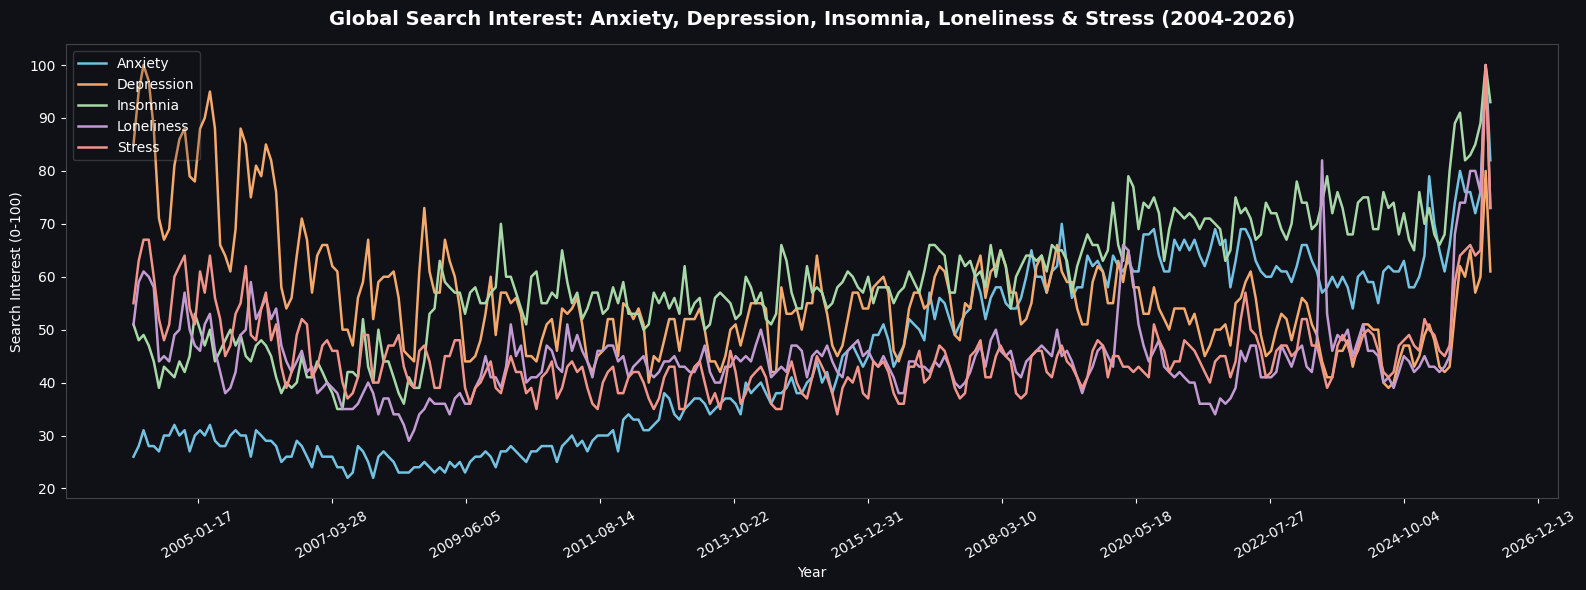

Saved 01_trend_lines.png


In [19]:
fig, ax = plt.subplots(figsize=(16, 6))
for concern, color in zip(CONCERNS, COLORS):
    ax.plot(df_monthly.index, df_monthly[concern],
            label=concern.capitalize(), color=color, linewidth=1.8)
ax.set_title('Global Search Interest: Anxiety, Depression, Insomnia, Loneliness & Stress (2004-2026)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Year'); ax.set_ylabel('Search Interest (0-100)')
ax.legend(loc='upper left', framealpha=0.2)
ax.xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_trend_lines.png', dpi=150)
plt.show()
print("Saved 01_trend_lines.png")

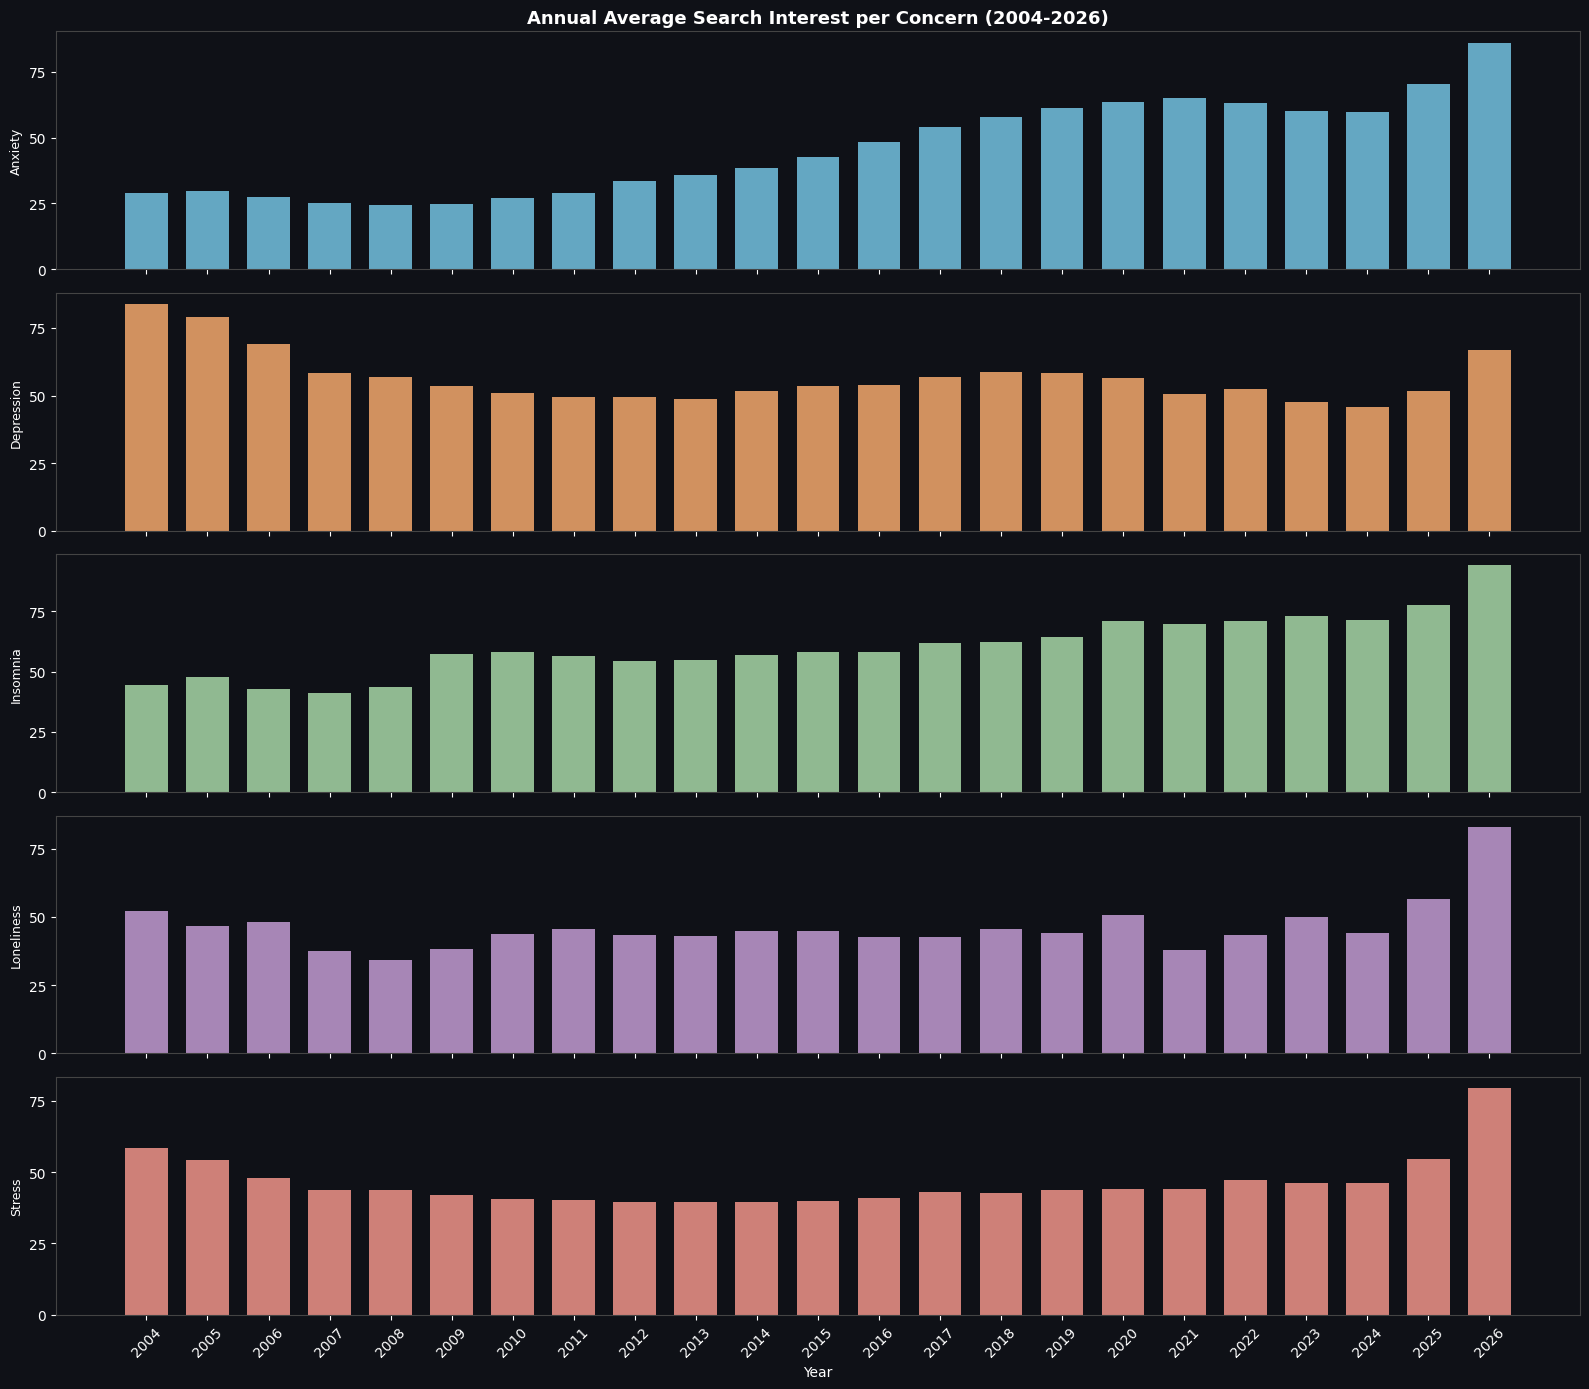

Saved 02_annual_bar.png


In [20]:
df_annual = df_monthly.resample('YE').mean()
df_annual.index = df_annual.index.year

fig, axes = plt.subplots(len(CONCERNS), 1, figsize=(16, 14), sharex=True)
for ax, concern, color in zip(axes, CONCERNS, COLORS):
    ax.bar(df_annual.index, df_annual[concern], color=color, alpha=0.85, width=0.7)
    ax.set_ylabel(concern.capitalize(), fontsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(4))
axes[0].set_title('Annual Average Search Interest per Concern (2004-2026)',
                  fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Year')
plt.xticks(df_annual.index, rotation=45); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_annual_bar.png', dpi=150)
plt.show()
print("Saved 02_annual_bar.png")

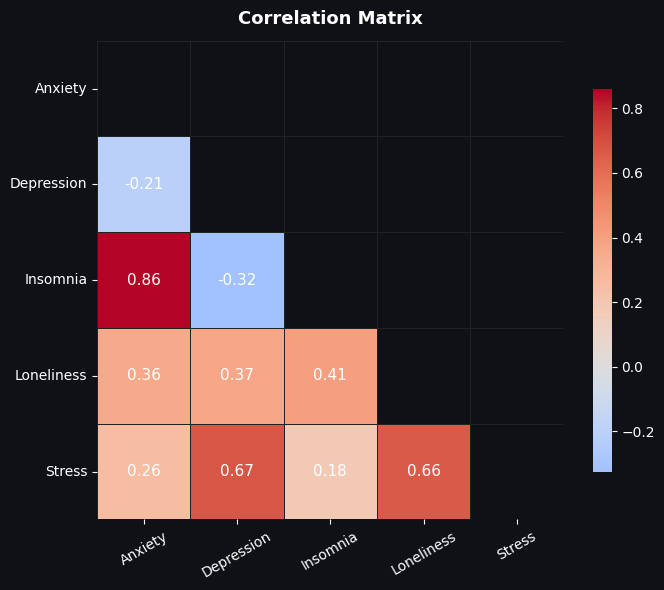

Saved 03_correlation_heatmap.png


In [21]:
corr = df_monthly[CONCERNS].corr()
fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='#222', ax=ax,
            annot_kws={'size': 11, 'color': 'white'}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels([c.capitalize() for c in CONCERNS], rotation=30)
ax.set_yticklabels([c.capitalize() for c in CONCERNS], rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_correlation_heatmap.png', dpi=150)
plt.show()
print("Saved 03_correlation_heatmap.png")

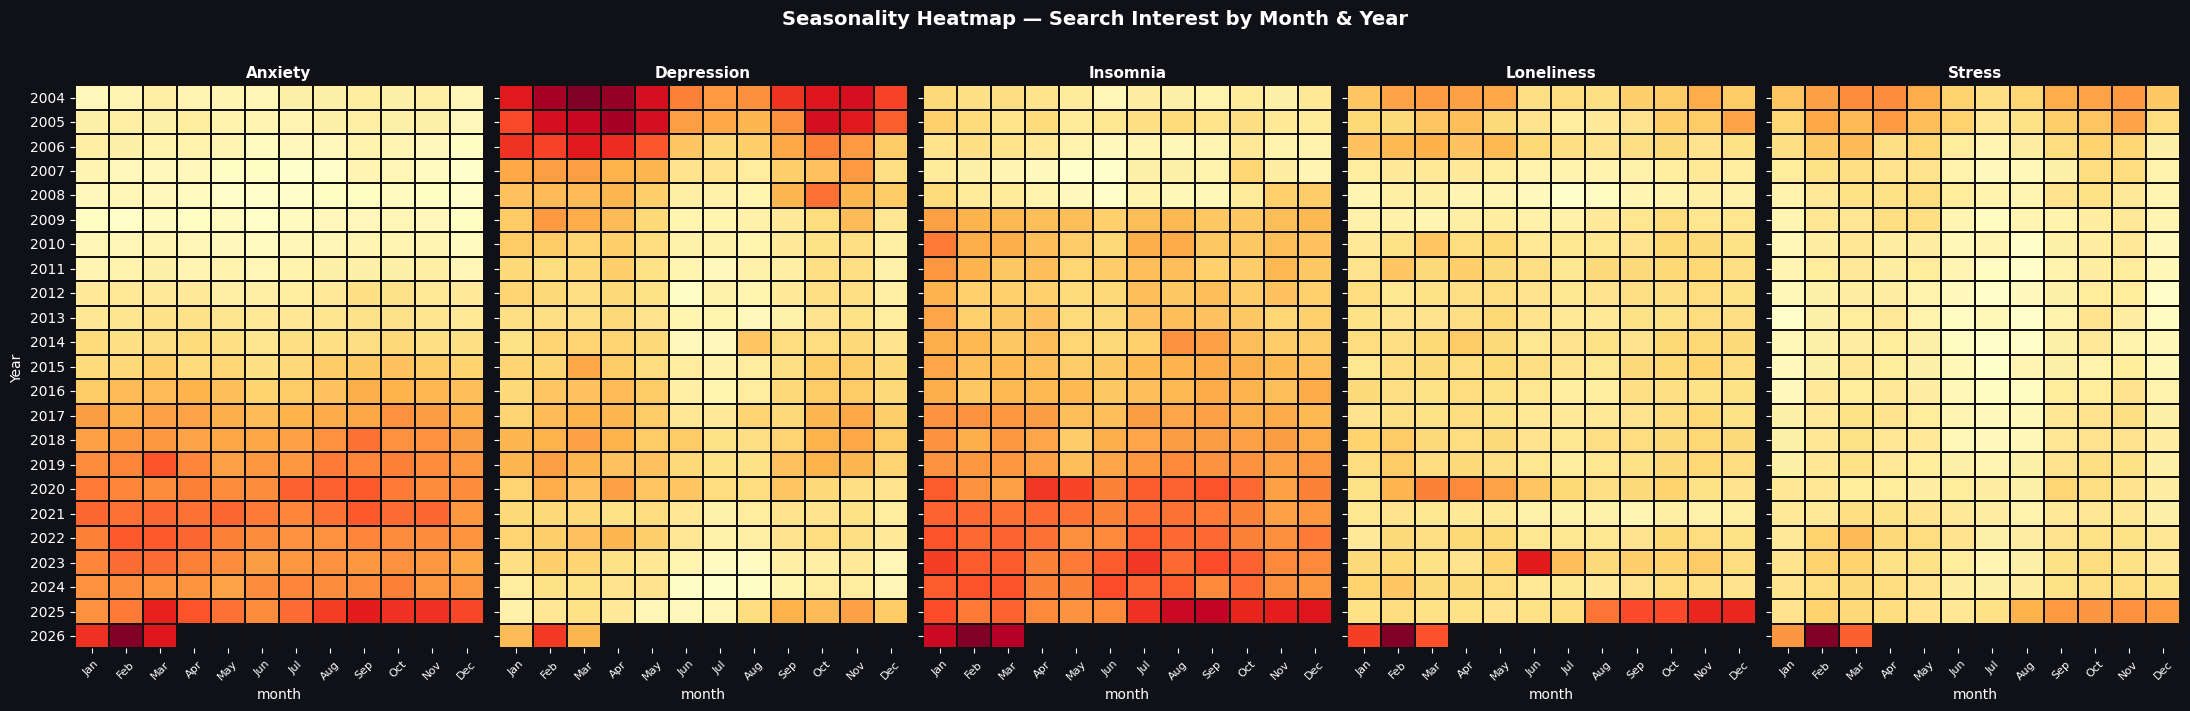

Saved 04_seasonality_heatmap.png


In [22]:
fig, axes = plt.subplots(1, len(CONCERNS), figsize=(22, 7), sharey=True)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for ax, concern in zip(axes, CONCERNS):
    pivot = df_monthly[concern].to_frame()
    pivot['year'] = pivot.index.year
    pivot['month'] = pivot.index.month
    table = pivot.pivot_table(index='year', columns='month', values=concern)
    sns.heatmap(table, ax=ax, cmap='YlOrRd', linewidths=0.3,
                linecolor='#111', cbar=False)
    ax.set_title(concern.capitalize(), fontsize=11, fontweight='bold')
    ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
    ax.set_ylabel('Year' if concern == 'anxiety' else '')

fig.suptitle('Seasonality Heatmap — Search Interest by Month & Year',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_seasonality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 04_seasonality_heatmap.png")

=== Z-Score Anomalies (|Z| > 2.0) ===

ANXIETY — 4 anomalies:
  2025-03  Z=+2.07  value=79.0
  2025-09  Z=+2.13  value=80.0
  2026-02  Z=+3.33  value=100.0
  2026-03  Z=+2.25  value=82.0

DEPRESSION — 18 anomalies:
  2004-01  Z=+2.53  value=85.0
  2004-02  Z=+3.41  value=95.0
  2004-03  Z=+3.85  value=100.0
  2004-04  Z=+3.58  value=97.0
  2004-05  Z=+2.79  value=88.0
  2004-09  Z=+2.17  value=81.0
  2004-10  Z=+2.62  value=86.0
  2004-11  Z=+2.79  value=88.0
  2005-02  Z=+2.79  value=88.0
  2005-03  Z=+2.97  value=90.0
  2005-04  Z=+3.41  value=95.0
  2005-05  Z=+2.79  value=88.0
  2005-10  Z=+2.79  value=88.0
  2005-11  Z=+2.53  value=85.0
  2006-01  Z=+2.17  value=81.0
  2006-03  Z=+2.53  value=85.0
  2006-04  Z=+2.26  value=82.0
  2026-02  Z=+2.09  value=80.0

INSOMNIA — 10 anomalies:
  2007-05  Z=-2.09  value=35.0
  2007-06  Z=-2.09  value=35.0
  2008-06  Z=-2.01  value=36.0
  2025-08  Z=+2.57  value=89.0
  2025-09  Z=+2.74  value=91.0
  2025-11  Z=+2.05  value=83.0
  2025-12  Z=+

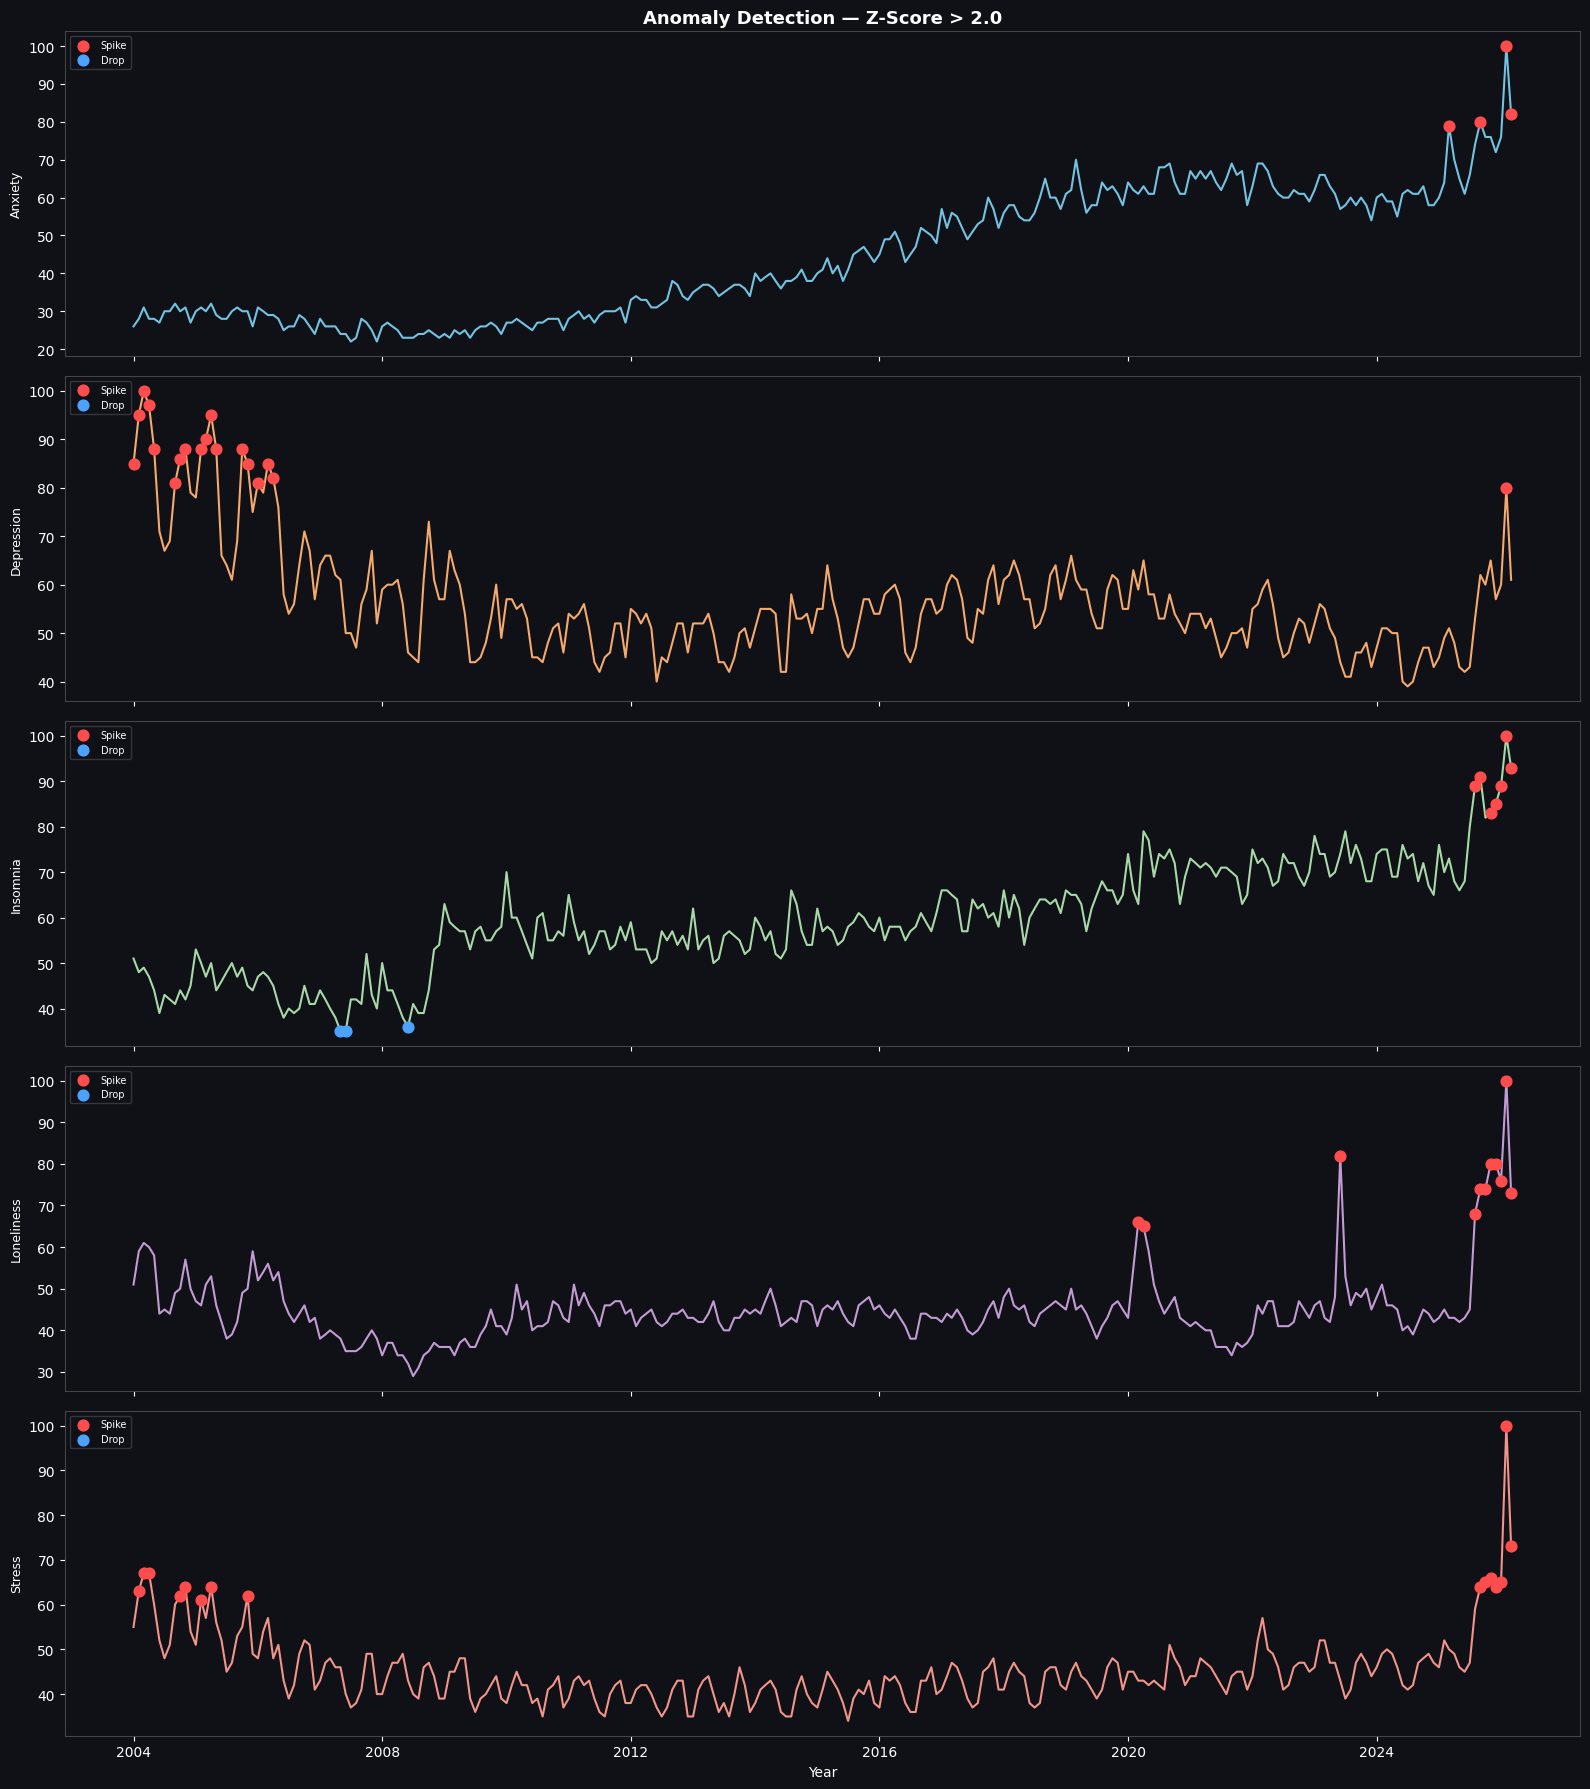

Saved 05_anomaly_overlay.png


In [23]:
df_zscore = df_monthly[CONCERNS].apply(stats.zscore)
THRESHOLD = 2.0
anomaly_records = []

print("=== Z-Score Anomalies (|Z| > 2.0) ===\n")
for concern in CONCERNS:
    anomalies = df_zscore[df_zscore[concern].abs() > THRESHOLD][concern]
    print(f"{concern.upper()} — {len(anomalies)} anomalies:")
    for date, z in anomalies.items():
        actual = df_monthly.loc[date, concern]
        direction = 'spike' if z > 0 else 'drop'
        print(f"  {date.strftime('%Y-%m')}  Z={z:+.2f}  value={actual:.1f}")
        anomaly_records.append({'date': date, 'concern': concern,
                                 'z_score': round(z, 3), 'value': round(actual, 2),
                                 'direction': direction})
    print()

df_anomalies = pd.DataFrame(anomaly_records).sort_values('date').reset_index(drop=True)

# Plot anomaly overlay
fig, axes = plt.subplots(len(CONCERNS), 1, figsize=(16, 18), sharex=True)
for ax, concern, color in zip(axes, CONCERNS, COLORS):
    ax.plot(df_monthly.index, df_monthly[concern], color=color, linewidth=1.5)
    subset = df_anomalies[df_anomalies['concern'] == concern]
    spikes = subset[subset['direction'] == 'spike']
    drops  = subset[subset['direction'] == 'drop']
    ax.scatter(spikes['date'], df_monthly.loc[spikes['date'], concern],
               color='#FF4C4C', zorder=5, s=60, label='Spike')
    ax.scatter(drops['date'],  df_monthly.loc[drops['date'],  concern],
               color='#4CA3FF', zorder=5, s=60, label='Drop')
    ax.set_ylabel(concern.capitalize(), fontsize=9)
    ax.legend(loc='upper left', fontsize=7, framealpha=0.2)

axes[0].set_title('Anomaly Detection — Z-Score > 2.0', fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_anomaly_overlay.png', dpi=150)
plt.show()
print("Saved 05_anomaly_overlay.png")

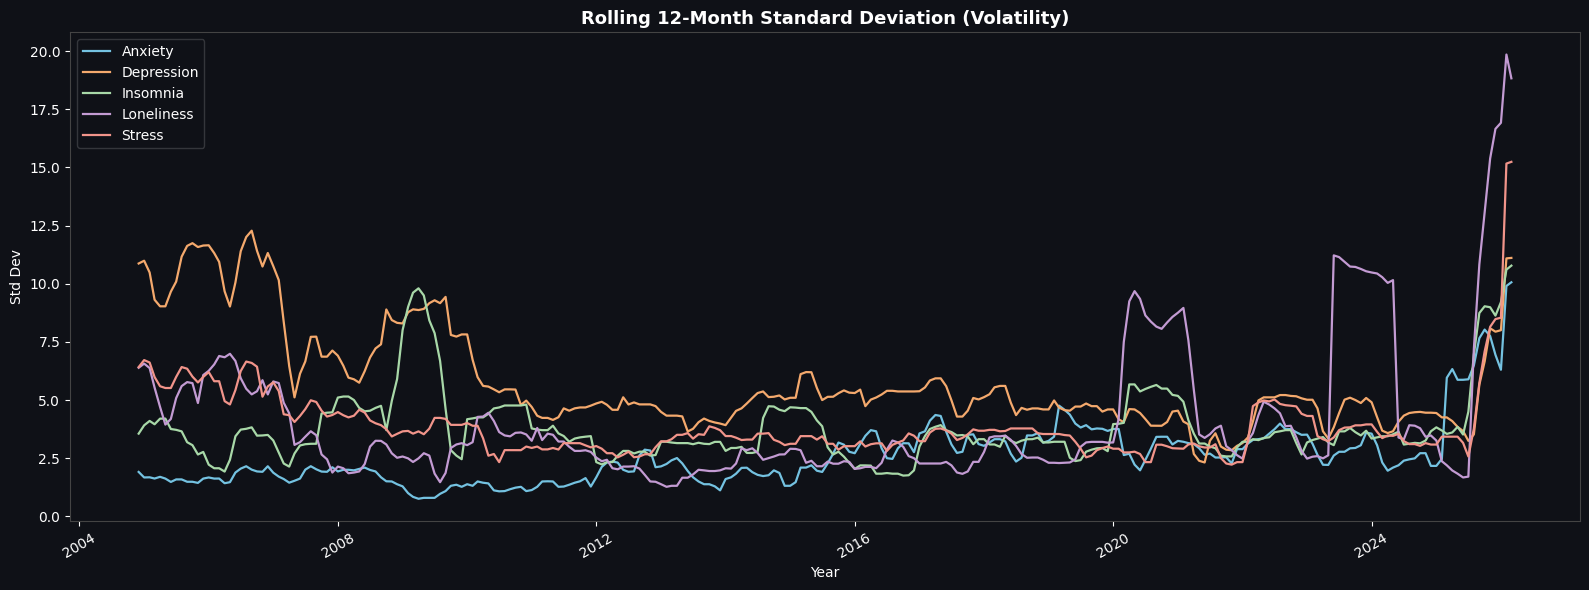

Saved 06_rolling_std.png

All CSVs saved to outputs folder.
Files ready for Power BI:
  01_trend_lines.png
  02_annual_bar.png
  03_correlation_heatmap.png
  04_seasonality_heatmap.png
  05_anomaly_overlay.png
  06_rolling_std.png
  powerbi_annual.csv
  powerbi_anomalies.csv
  powerbi_monthly.csv
  powerbi_raw.csv
  powerbi_rolling_std.csv
  powerbi_zscores.csv


In [24]:
# Rolling standard deviation
WINDOW = 12
df_rolling_std = df_monthly[CONCERNS].rolling(window=WINDOW).std()

fig, ax = plt.subplots(figsize=(16, 6))
for concern, color in zip(CONCERNS, COLORS):
    ax.plot(df_rolling_std.index, df_rolling_std[concern],
            label=concern.capitalize(), color=color, linewidth=1.6)
ax.set_title(f'Rolling {WINDOW}-Month Standard Deviation (Volatility)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Std Dev')
ax.legend(loc='upper left', framealpha=0.2)
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_rolling_std.png', dpi=150)
plt.show()
print("Saved 06_rolling_std.png")

# Export all CSVs for Power BI
df_monthly.to_csv(f'{OUTPUT_DIR}/powerbi_monthly.csv', index_label='date')
df[CONCERNS].to_csv(f'{OUTPUT_DIR}/powerbi_raw.csv', index_label='date')
df_monthly.resample('YE').mean().to_csv(f'{OUTPUT_DIR}/powerbi_annual.csv', index_label='year')
df_zscore.to_csv(f'{OUTPUT_DIR}/powerbi_zscores.csv', index_label='date')
df_anomalies.to_csv(f'{OUTPUT_DIR}/powerbi_anomalies.csv', index=False)
df_rolling_std.to_csv(f'{OUTPUT_DIR}/powerbi_rolling_std.csv', index_label='date')

print("\nAll CSVs saved to outputs folder.")
print("Files ready for Power BI:")
for f in os.listdir(OUTPUT_DIR):
    print(f"  {f}")

In [25]:
import os
OUTPUT_DIR = r'C:\Users\admin\OneDrive\Desktop\human-concern-timeseries\outputs'
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f)

01_trend_lines.png
02_annual_bar.png
03_correlation_heatmap.png
04_seasonality_heatmap.png
05_anomaly_overlay.png
06_rolling_std.png
powerbi_annual.csv
powerbi_anomalies.csv
powerbi_monthly.csv
powerbi_raw.csv
powerbi_rolling_std.csv
powerbi_zscores.csv


In [26]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 28))
fig.suptitle('STL Decomposition — Trend, Seasonality & Residual per Concern',
             fontsize=15, fontweight='bold', y=1.01)

for i, (concern, color) in enumerate(zip(CONCERNS, COLORS)):
    series = df_monthly[concern].dropna()
    stl = STL(series, period=12, robust=True)
    result = stl.fit()

    gs = gridspec.GridSpecFromSubplotSpec(4, 1,
         subplot_spec=gridspec.GridSpec(len(CONCERNS), 1, figure=fig)[i],
         hspace=0.15)

    axes = [fig.add_subplot(gs[j]) for j in range(4)]
    components = [
        (series,           'Observed'),
        (result.trend,     'Trend'),
        (result.seasonal,  'Seasonality'),
        (result.resid,     'Residual'),
    ]

    for ax, (data, label) in zip(axes, components):
        ax.plot(data.index, data.values, color=color, linewidth=1.2)
        ax.set_ylabel(label, fontsize=8)

ModuleNotFoundError: No module named 'statsmodels'

In [29]:
import subprocess
subprocess.run(['pip', 'install', 'statsmodels'], capture_output=True)
print("Done")

Done


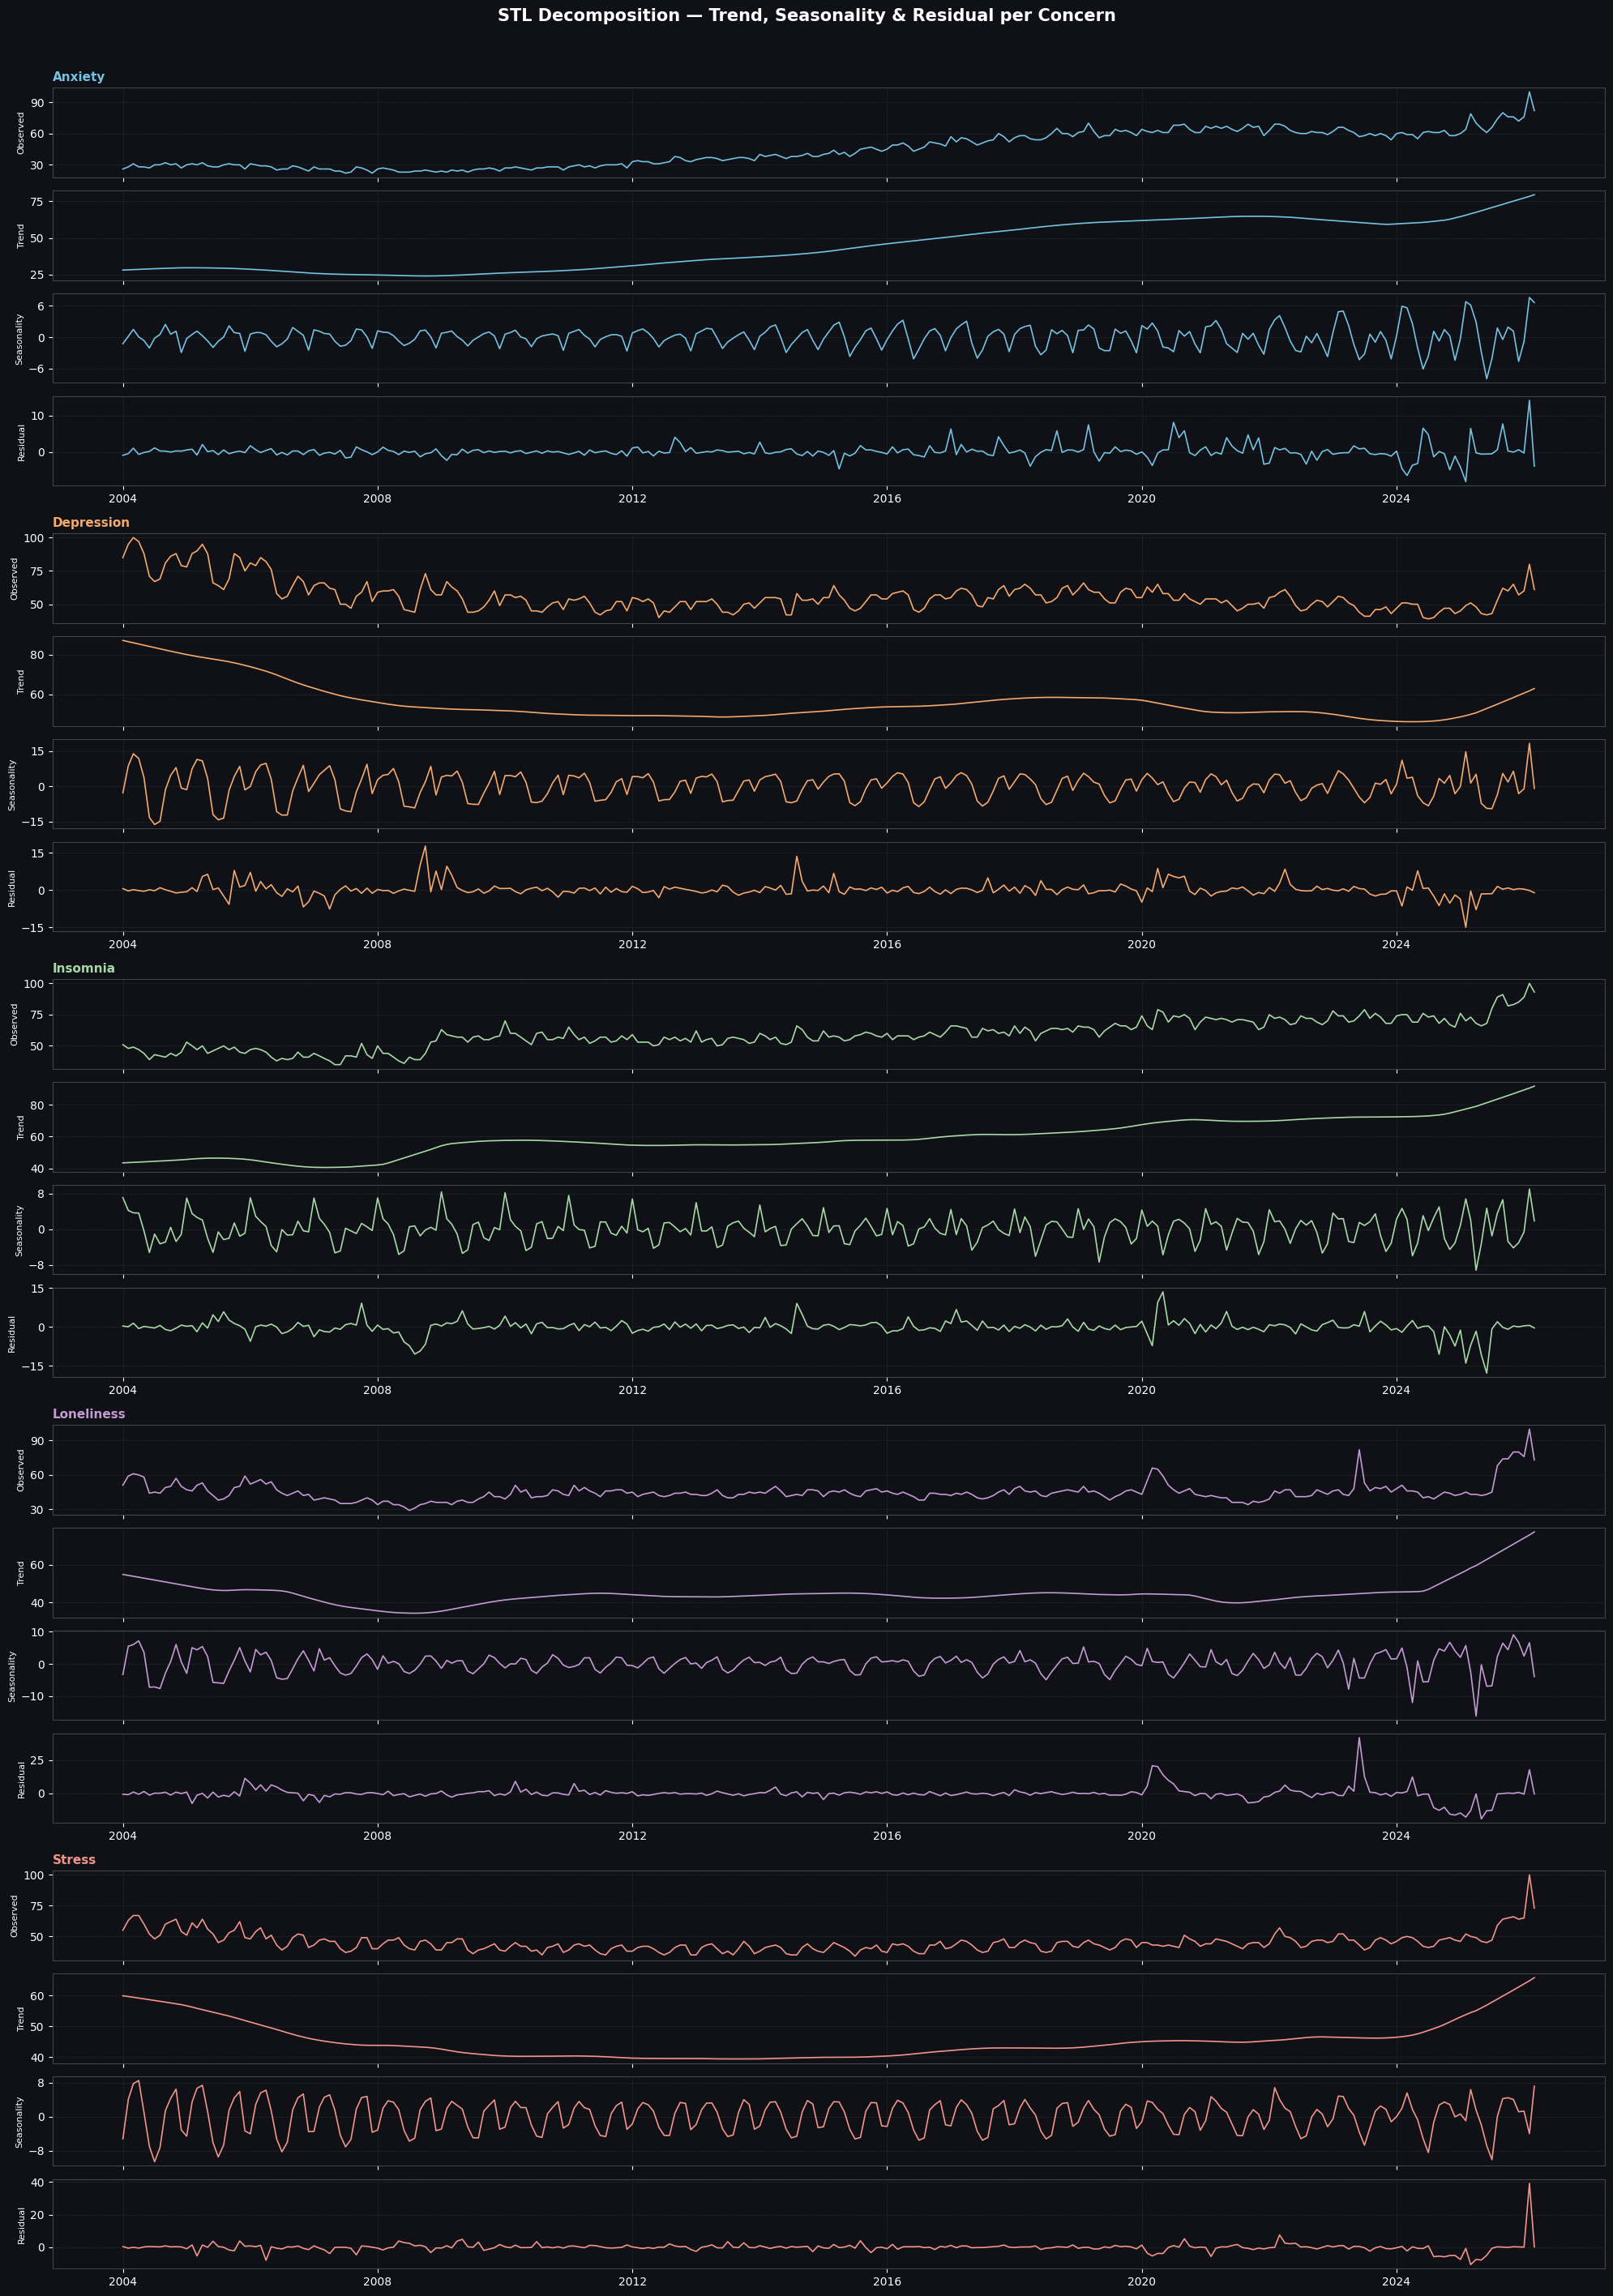

Saved 07_stl_decomposition.png


In [30]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 28))
fig.suptitle('STL Decomposition — Trend, Seasonality & Residual per Concern',
             fontsize=15, fontweight='bold', y=1.01)

for i, (concern, color) in enumerate(zip(CONCERNS, COLORS)):
    series = df_monthly[concern].dropna()
    stl = STL(series, period=12, robust=True)
    result = stl.fit()

    gs = gridspec.GridSpecFromSubplotSpec(4, 1,
         subplot_spec=gridspec.GridSpec(len(CONCERNS), 1, figure=fig)[i],
         hspace=0.15)

    axes = [fig.add_subplot(gs[j]) for j in range(4)]
    components = [
        (series,           'Observed'),
        (result.trend,     'Trend'),
        (result.seasonal,  'Seasonality'),
        (result.resid,     'Residual'),
    ]

    for ax, (data, label) in zip(axes, components):
        ax.plot(data.index, data.values, color=color, linewidth=1.2)
        ax.set_ylabel(label, fontsize=8)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
        if label != 'Residual':
            ax.set_xticklabels([])
        ax.grid(True)

    axes[0].set_title(concern.capitalize(), fontsize=11, fontweight='bold',
                      color=color, loc='left')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 07_stl_decomposition.png")

In [31]:
stl_records = []

for concern in CONCERNS:
    series = df_monthly[concern].dropna()
    stl = STL(series, period=12, robust=True)
    result = stl.fit()

    for date in series.index:
        stl_records.append({
            'date':      date,
            'concern':   concern,
            'observed':  round(series[date], 4),
            'trend':     round(result.trend[date], 4),
            'seasonal':  round(result.seasonal[date], 4),
            'residual':  round(result.resid[date], 4),
        })

df_stl = pd.DataFrame(stl_records).sort_values(['concern', 'date']).reset_index(drop=True)
df_stl.to_csv(f'{OUTPUT_DIR}/powerbi_stl.csv', index=False)

print("Saved powerbi_stl.csv")
print(f"Shape: {df_stl.shape}")
print(df_stl.head(10))

Saved powerbi_stl.csv
Shape: (1335, 6)
        date  concern  observed    trend  seasonal  residual
0 2004-01-01  anxiety        26  28.1505   -1.2358   -0.9147
1 2004-02-01  anxiety        28  28.3128    0.1478   -0.4605
2 2004-03-01  anxiety        31  28.4706    1.4842    1.0452
3 2004-04-01  anxiety        28  28.6242    0.0485   -0.6727
4 2004-05-01  anxiety        28  28.7735   -0.6399   -0.1336
5 2004-06-01  anxiety        27  28.9187   -2.0510    0.1323
6 2004-07-01  anxiety        30  29.0601   -0.1940    1.1338
7 2004-08-01  anxiety        30  29.1981    0.5339    0.2680
8 2004-09-01  anxiety        32  29.3323    2.4386    0.2291
9 2004-10-01  anxiety        30  29.4619    0.5668   -0.0287


In [32]:
import subprocess
subprocess.run(['pip', 'install', 'prophet'], capture_output=True)
print("Done")

Done


Importing plotly failed. Interactive plots will not work.
17:02:33 - cmdstanpy - INFO - Chain [1] start processing
17:02:34 - cmdstanpy - INFO - Chain [1] done processing
17:02:34 - cmdstanpy - INFO - Chain [1] start processing
17:02:34 - cmdstanpy - INFO - Chain [1] done processing
17:02:35 - cmdstanpy - INFO - Chain [1] start processing
17:02:35 - cmdstanpy - INFO - Chain [1] done processing
17:02:35 - cmdstanpy - INFO - Chain [1] start processing
17:02:36 - cmdstanpy - INFO - Chain [1] done processing
17:02:36 - cmdstanpy - INFO - Chain [1] start processing
17:02:36 - cmdstanpy - INFO - Chain [1] done processing


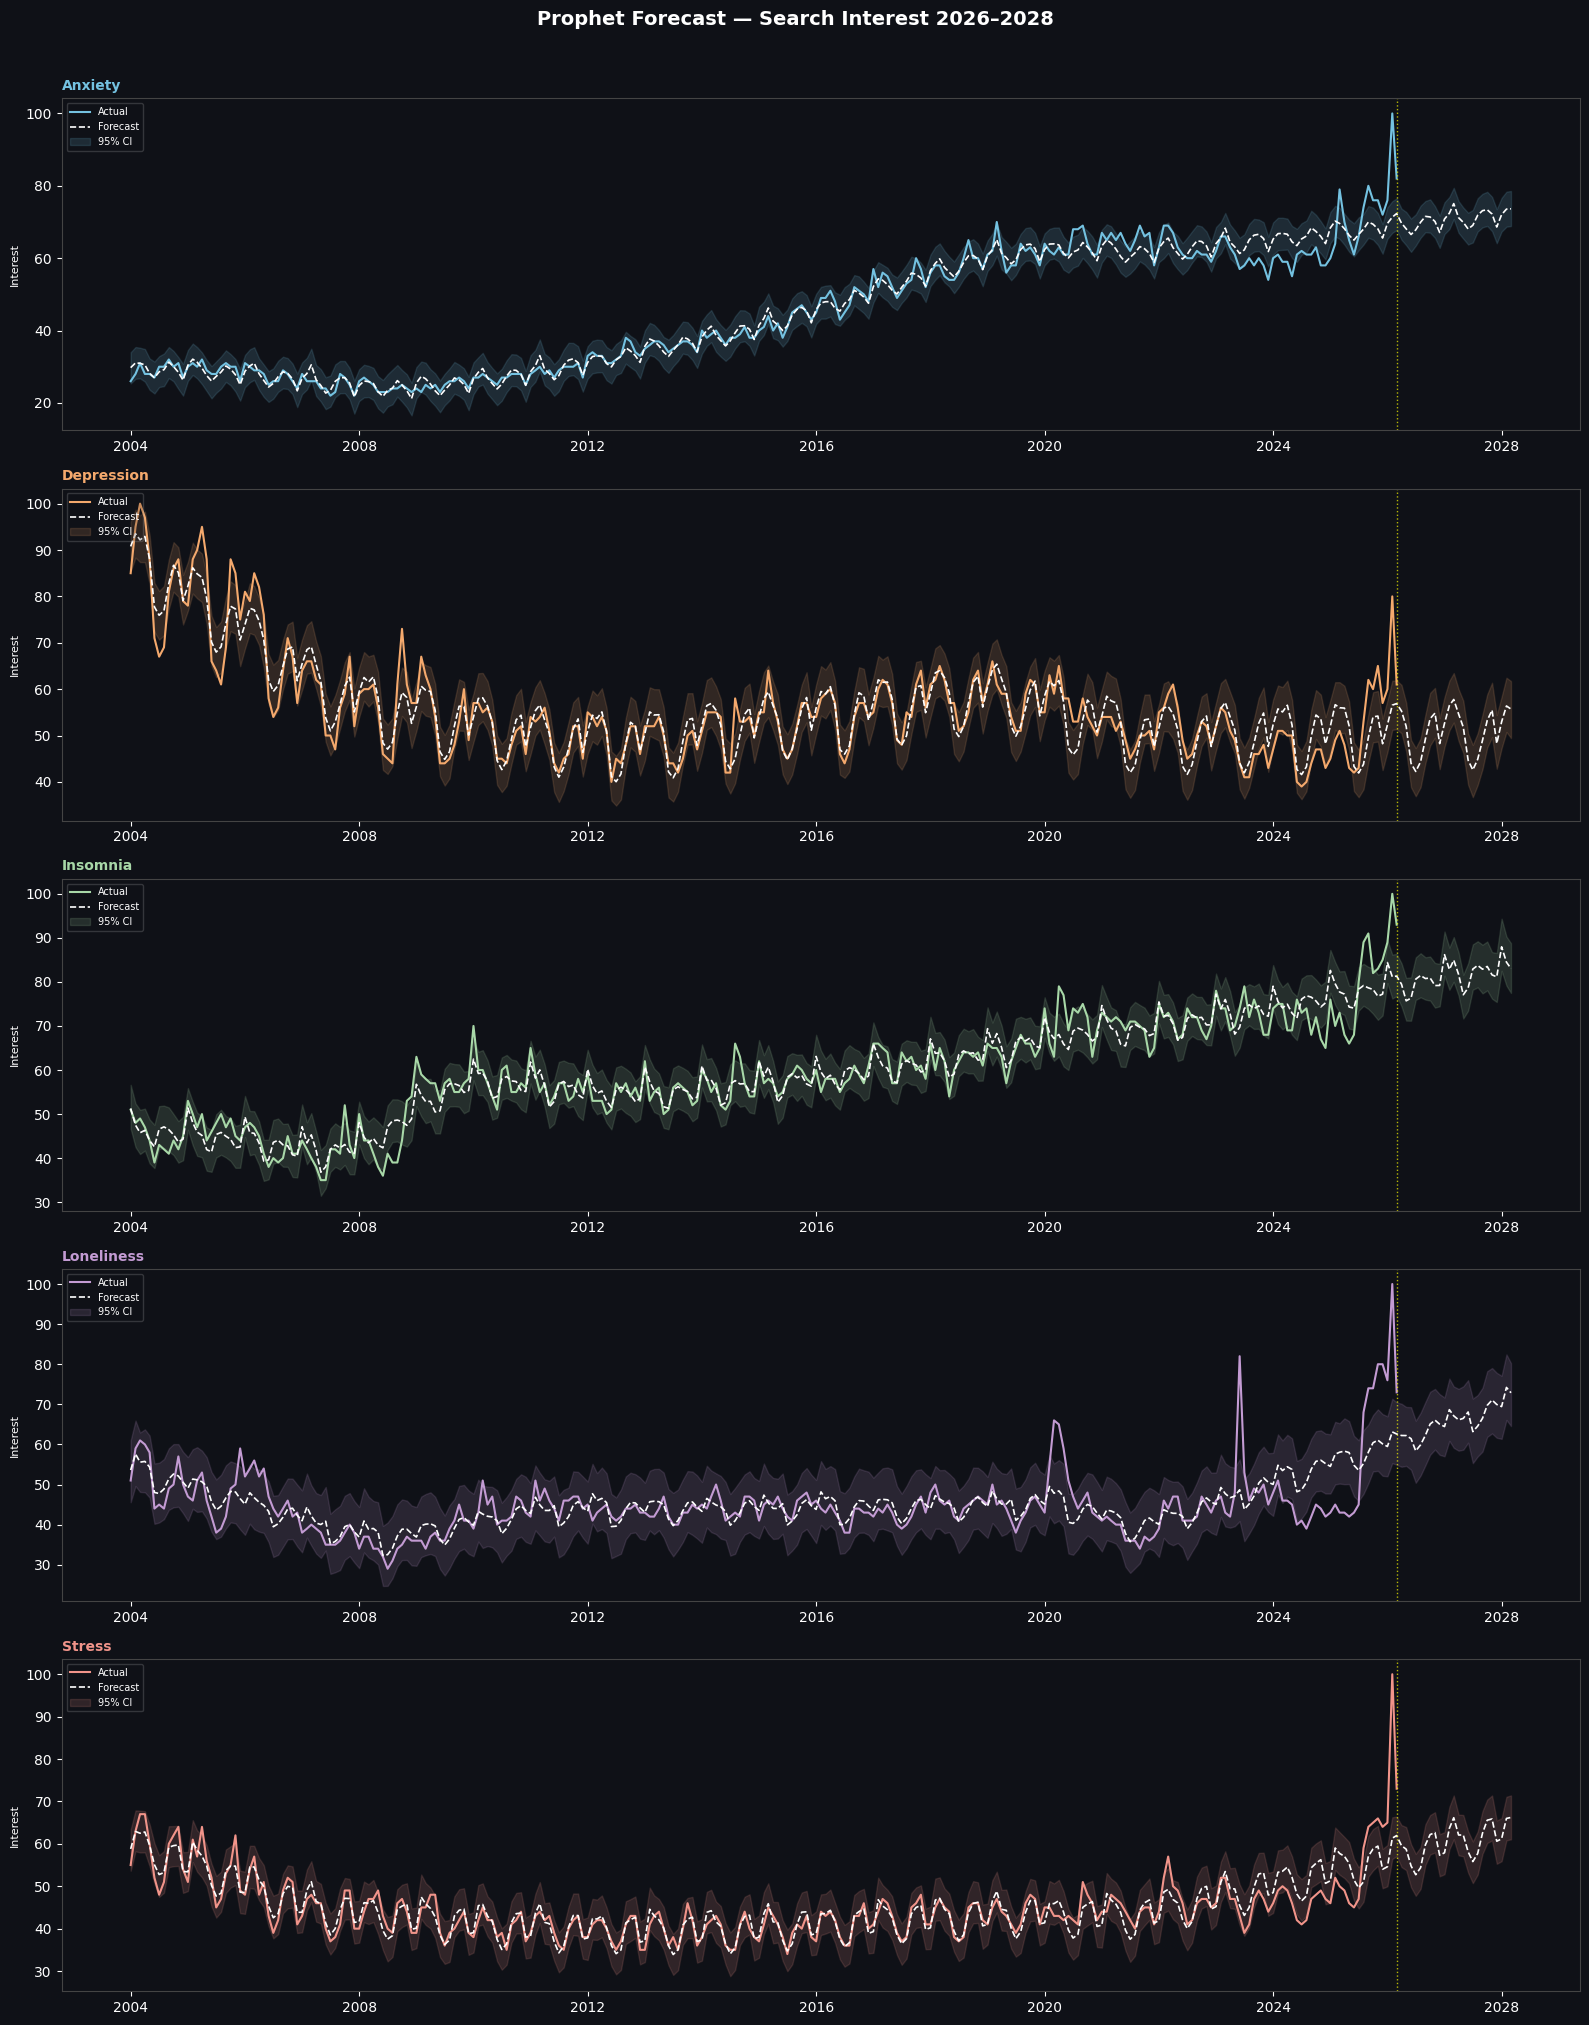

Saved 08_prophet_forecast.png
Saved powerbi_forecast.csv — 120 rows
        date  concern  forecast  lower  upper
0 2026-04-01  anxiety     69.68  65.09  73.68
1 2026-05-01  anxiety     68.10  63.57  72.78
2 2026-06-01  anxiety     66.54  61.73  70.94
3 2026-07-01  anxiety     67.82  63.46  72.10
4 2026-08-01  anxiety     69.93  65.61  74.50
5 2026-09-01  anxiety     71.55  67.19  75.80
6 2026-10-01  anxiety     71.38  67.04  76.25
7 2026-11-01  anxiety     70.14  65.61  74.38
8 2026-12-01  anxiety     67.10  62.84  71.75
9 2027-01-01  anxiety     70.82  66.65  75.43


In [33]:
from prophet import Prophet

FORECAST_MONTHS = 24  # predict 2 years ahead
forecast_records = []

fig, axes = plt.subplots(len(CONCERNS), 1, figsize=(16, 20), sharex=False)

for ax, concern, color in zip(axes, CONCERNS, COLORS):
    # Prophet requires columns named 'ds' and 'y'
    prophet_df = df_monthly[[concern]].reset_index()
    prophet_df.columns = ['ds', 'y']
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.3,
        seasonality_mode='additive'
    )
    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=FORECAST_MONTHS, freq='MS')
    forecast = model.predict(future)

    # Store forecast records
    for _, row in forecast[forecast['ds'] > df_monthly.index.max()].iterrows():
        forecast_records.append({
            'date':       row['ds'],
            'concern':    concern,
            'forecast':   round(row['yhat'], 2),
            'lower':      round(row['yhat_lower'], 2),
            'upper':      round(row['yhat_upper'], 2),
        })

    # Plot
    ax.plot(prophet_df['ds'], prophet_df['y'],
            color=color, linewidth=1.5, label='Actual')
    ax.plot(forecast['ds'], forecast['yhat'],
            color='white', linewidth=1.2, linestyle='--', label='Forecast')
    ax.fill_between(forecast['ds'],
                    forecast['yhat_lower'], forecast['yhat_upper'],
                    color=color, alpha=0.15, label='95% CI')
    ax.axvline(df_monthly.index.max(), color='yellow',
               linestyle=':', linewidth=1, alpha=0.7)
    ax.set_title(concern.capitalize(), fontsize=10, fontweight='bold',
                 color=color, loc='left')
    ax.set_ylabel('Interest', fontsize=8)
    ax.legend(loc='upper left', fontsize=7, framealpha=0.2)

fig.suptitle('Prophet Forecast — Search Interest 2026–2028',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 08_prophet_forecast.png")

# Export forecast CSV
df_forecast = pd.DataFrame(forecast_records).sort_values(['concern','date']).reset_index(drop=True)
df_forecast.to_csv(f'{OUTPUT_DIR}/powerbi_forecast.csv', index=False)
print(f"Saved powerbi_forecast.csv — {len(df_forecast)} rows")
print(df_forecast.head(10))